In [3]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

import dask

from dask.distributed import Client
import multiprocessing

ncpu = multiprocessing.cpu_count()
threads = 8
nworker = ncpu // threads
print(
    f"Number of CPUs: {ncpu}, number of threads: {threads}, number of workers: {nworker}"
)
client = Client(
    processes=True, threads_per_worker=threads, n_workers=nworker, memory_limit="100GB"
)
client 

# calculation
import metpy.calc as mpcalc

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# basic
from pathlib import Path # Object oriented libary to deal with paths
from dask.utils import format_bytes
from distributed import Client, progress, wait # Libaray to orchestrate distributed resources
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data

# dask
import dask # Distributed data libary
import dask.distributed
import multiprocessing
from subprocess import run, PIPE
import warnings
warnings.filterwarnings(action='ignore')
import pandas as pd
dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})

Number of CPUs: 256, number of threads: 8, number of workers: 32


In [4]:
import sys
sys.path.append('/home/m/m300948/ICON_AMZDEF')
import Tools

## Load datasets

In [3]:
# K
ta_ctl = xr.open_mfdataset('/scratch/m/m300948/test_04/3d/ta/6hourly/ctl_daily_ta_plev_2022*',parallel=True)['ta']
ta_def = xr.open_mfdataset('/scratch/m/m300948/def_100/3d/ta/6hourly/def_daily_ta_plev_2022*',parallel=True)['ta']

In [4]:
# kg/kg
qa_ctl = xr.open_mfdataset('/scratch/m/m300948/test_04/3d/specif_humidity/6hourly/ctl_daily_hus_plev_2022*',parallel=True)['hus']
qa_def = xr.open_mfdataset('/scratch/m/m300948/def_100/3d/specif_humidity/6hourly/def_daily_hus_plev_2022*',parallel=True)['hus']

In [5]:
ta_ctl_wet = ta_ctl.where(ta_ctl.time.dt.month.isin([1, 2, 12]), drop=True)
ta_def_wet = ta_def.where(ta_def.time.dt.month.isin([1, 2, 12]), drop=True)

In [6]:
qa_ctl_wet = qa_ctl.where(qa_ctl.time.dt.month.isin([1, 2, 12]), drop=True)
qa_def_wet = qa_def.where(qa_def.time.dt.month.isin([1, 2, 12]), drop=True)

In [7]:
ta_ctl_dry = ta_ctl.where(ta_ctl.time.dt.month.isin([7, 8, 9]), drop=True)
ta_def_dry = ta_def.where(ta_def.time.dt.month.isin([7, 8, 9]), drop=True)

In [8]:
qa_ctl_dry = qa_ctl.where(qa_ctl.time.dt.month.isin([7, 8, 9]), drop=True)
qa_def_dry = qa_def.where(qa_def.time.dt.month.isin([7, 8, 9]), drop=True)

In [9]:
# Get the time indices where the hour is 0, 6, 12, 18
ta_ctl_dry_18utc = ta_ctl_dry.sel(time=(ta_ctl_dry.time.dt.hour == 18)).mean(dim='time')
ta_def_dry_18utc = ta_def_dry.sel(time=(ta_def_dry.time.dt.hour == 18)).mean(dim='time')

In [10]:
# Get the time indices where the hour is 0, 6, 12, 18
ta_ctl_wet_18utc = ta_ctl_wet.sel(time=(ta_ctl_wet.time.dt.hour == 18)).mean(dim='time')
ta_def_wet_18utc = ta_def_wet.sel(time=(ta_def_wet.time.dt.hour == 18)).mean(dim='time')

In [11]:
qa_ctl_dry_18utc = qa_ctl_dry.sel(time=(qa_ctl_dry.time.dt.hour == 18)).mean(dim='time')
qa_def_dry_18utc = qa_def_dry.sel(time=(qa_def_dry.time.dt.hour == 18)).mean(dim='time')

In [12]:
qa_ctl_wet_18utc = qa_ctl_wet.sel(time=(qa_ctl_wet.time.dt.hour == 18)).mean(dim='time')
qa_def_wet_18utc = qa_def_wet.sel(time=(qa_def_wet.time.dt.hour == 18)).mean(dim='time')

_domain_

In [13]:
lat_start = -17
lat_end = 9
lon_start = -80
lon_end = -45

In [14]:
ta_ctl_dry_18utc_sel = ta_ctl_dry_18utc.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
ta_ctl_wet_18utc_sel = ta_ctl_wet_18utc.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
ta_def_dry_18utc_sel = ta_def_dry_18utc.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
ta_def_wet_18utc_sel = ta_def_wet_18utc.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))

In [15]:
qa_ctl_dry_18utc_sel = qa_ctl_dry_18utc.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
qa_ctl_wet_18utc_sel = qa_ctl_wet_18utc.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
qa_def_dry_18utc_sel = qa_def_dry_18utc.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))
qa_def_wet_18utc_sel = qa_def_wet_18utc.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))

In [16]:
# CTL
press = ta_ctl_dry.plev.broadcast_like(ta_ctl_dry_18utc_sel) /100 

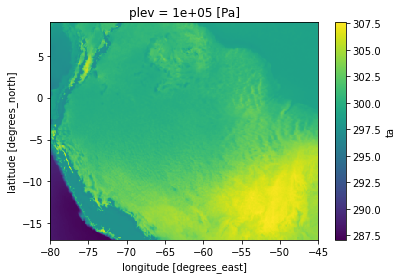

In [17]:
ta_ctl_dry_18utc_sel.isel(plev=0).plot()

_add unit_

In [18]:
from metpy.units import units

In [19]:
press_hPa = press * units.hPa

In [20]:
xarray_names = ['ta_ctl_dry','ta_ctl_wet','ta_def_dry','ta_def_wet']
new_suffix = '_18utc_sel_degC'

for name in xarray_names:
    dset_name = name + '_18utc_sel'
    xarray_data = globals()[dset_name]
    
    xarray_data_degC = xarray_data - 273.15
    
    new_name = name + new_suffix
    globals()[new_name] = xarray_data_degC

In [21]:
ta_ctl_dry_18utc_degC = ta_ctl_dry_18utc_sel_degC * units.degC
ta_def_dry_18utc_degC = ta_def_dry_18utc_sel_degC * units.degC
ta_ctl_wet_18utc_degC = ta_ctl_wet_18utc_sel_degC * units.degC
ta_def_wet_18utc_degC = ta_def_wet_18utc_sel_degC * units.degC

## Calculate the specific humidity

In [22]:
from metpy.calc import relative_humidity_from_specific_humidity
from metpy.calc import cape_cin, dewpoint_from_relative_humidity, parcel_profile

In [23]:
rh_ctl_dry = relative_humidity_from_specific_humidity(press_hPa, ta_ctl_dry_18utc_degC, qa_ctl_dry_18utc_sel)
rh_ctl_wet = relative_humidity_from_specific_humidity(press_hPa, ta_ctl_wet_18utc_degC, qa_ctl_wet_18utc_sel)
rh_def_dry = relative_humidity_from_specific_humidity(press_hPa, ta_def_dry_18utc_degC, qa_def_dry_18utc_sel)
rh_def_wet = relative_humidity_from_specific_humidity(press_hPa, ta_def_wet_18utc_degC, qa_def_wet_18utc_sel)

In [24]:
# ta with degC and rh with percent
td_ctl_dry = dewpoint_from_relative_humidity(ta_ctl_dry_18utc_degC, rh_ctl_dry * 100 * units.percent)
td_ctl_wet = dewpoint_from_relative_humidity(ta_ctl_wet_18utc_degC, rh_ctl_wet * 100 * units.percent)
td_def_dry = dewpoint_from_relative_humidity(ta_def_dry_18utc_degC, rh_def_dry *  100 * units.percent)
td_def_wet = dewpoint_from_relative_humidity(ta_def_wet_18utc_degC, rh_def_wet *  100 * units.percent)

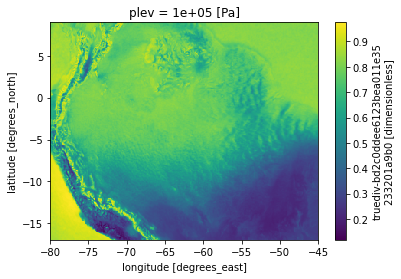

In [25]:
rh_ctl_dry.isel(plev=0).plot()

In [ ]:
td_ctl_dry

## Calculate CAPE, CIN

In [25]:
import xarray as xr
import numpy as np
from metpy.units import units
from metpy.calc import cape_cin, parcel_profile

def cal_cape_cin(pressure_data, temperature_data, dew_temperature_data):
    """
    Function to calculate CAPE and CIN for a single grid point.
    """
    T = temperature_data * units.degC
    Td = dew_temperature_data * units.degC
    p = pressure_data * units.hPa
    
    #print(p, T[0], Td[0])
  
    prof = parcel_profile(p, T[0], Td[0]).to('degC')
    cape, cin = cape_cin(p, T, Td, prof)
    return cape.magnitude, cin.magnitude

In [31]:
# Apply xr.apply_ufunc
cape_cin_ctl_result = xr.apply_ufunc(
    cal_cape_cin,
    press_hPa.load(),
    ta_ctl_wet_18utc_degC.load(),
    td_ctl_wet.load(),
    input_core_dims=[['plev'], ['plev'], ['plev']], 
    output_core_dims=[[],[]],
    vectorize=True,  # Vectorize the operation
    dask='parallelized',  # Use parallelized computation if using dask
    output_dtypes=[float, float]
)

/home/m/m300948/.conda/envs/JUPYTER_MODULE/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in log
  return func(*(_execute_task(a, cache) for a in args))


In [97]:
# Apply xr.apply_ufunc
cape_cin_def_result = xr.apply_ufunc(
    cal_cape_cin,
    press_hPa.load(),
    ta_def_wet_18utc_degC.load(),
    td_def_wet.load(),
    input_core_dims=[['plev'], ['plev'], ['plev']], 
    output_core_dims=[[],[]],
    vectorize=True,  # Vectorize the operation
    dask='parallelized',  # Use parallelized computation if using dask
    output_dtypes=[float, float]
)

/home/m/m300948/.conda/envs/JUPYTER_MODULE/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: invalid value encountered in log
  return func(*(_execute_task(a, cache) for a in args))


In [26]:
# Apply xr.apply_ufunc and dask 
cape_cin_ctl_result = xr.apply_ufunc(
    cal_cape_cin,
    press_hPa,
    ta_ctl_wet_18utc_degC,
    td_ctl_wet,
    input_core_dims=[['plev'], ['plev'], ['plev']], 
    output_core_dims=[[],[]],
    vectorize=True,  # Vectorize the operation
    dask='parallelized',  # Use parallelized computation if using dask
    output_dtypes=[float, float]
)

In [32]:
# CTL dry
cape_ctl_dry = cape_cin_ctl_result[0]
cin_ctl_dry = cape_cin_ctl_result[1]

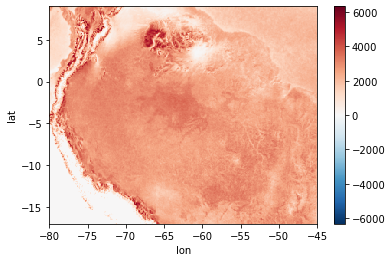

In [33]:
cape_ctl_dry.plot()

In [69]:
# DEF dry
cape_def_dry = cape_cin_def_result[0]
cin_def_dry = cape_cin_def_result[1]

In [98]:
# CTL wet
cape_ctl_wet = cape_cin_ctl_result[0]
cin_ctl_wet = cape_cin_ctl_result[1]

In [99]:
# DEF wet
cape_def_wet = cape_cin_def_result[0]
cin_def_wet = cape_cin_def_result[1]

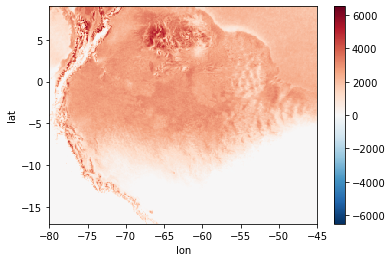

In [46]:
cape_ctl_dry.plot()

## Mask out Amazon region

In [28]:
dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
AMZ_BD = dset_bd.AMAZON_BIOMES

In [48]:
ABinterp_biome = AMZ_BD.interp(latitude=cape_ctl_dry.lat, longitude=cape_ctl_dry.lon)

In [56]:
cape_ctl_dry_mask = cape_ctl_dry.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [70]:
cape_def_dry_mask = cape_def_dry.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [100]:
cape_ctl_wet_mask = cape_ctl_wet.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [101]:
cape_def_wet_mask = cape_def_wet.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [57]:
ta_ctl_dry_18utc_degC_mask = ta_ctl_dry_18utc_degC.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [71]:
ta_def_dry_18utc_degC_mask = ta_def_dry_18utc_degC.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [102]:
ta_ctl_wet_18utc_degC_mask = ta_ctl_wet_18utc_degC.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [103]:
ta_def_wet_18utc_degC_mask = ta_def_wet_18utc_degC.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [58]:
qa_ctl_dry_18utc_sel_mask = qa_ctl_dry_18utc_sel.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [72]:
qa_def_dry_18utc_sel_mask = qa_def_dry_18utc_sel.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [104]:
qa_ctl_wet_18utc_sel_mask = qa_ctl_wet_18utc_sel.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

In [105]:
qa_def_wet_18utc_sel_mask = qa_def_wet_18utc_sel.where(ABinterp_biome == 0, np.nan).sel(lon=slice(-80,-40), lat=slice(-20,10))

## Frequency figures

In [59]:
# Step 1: Flatten all datasets to 1D and remove NaN values
cape_ctl_mask_flat = cape_ctl_dry_mask.values.flatten()
ta_ctl_dry_mask_flat = ta_ctl_dry_18utc_degC_mask.sel(plev=100000).values.flatten()
qa_ctl_dry_mask_flat = qa_ctl_dry_18utc_sel_mask.sel(plev=100000).values.flatten()

In [73]:
# Step 1: Flatten all datasets to 1D and remove NaN values
cape_def_mask_flat = cape_def_dry_mask.values.flatten()
ta_def_dry_mask_flat = ta_def_dry_18utc_degC_mask.sel(plev=100000).values.flatten()
qa_def_dry_mask_flat = qa_def_dry_18utc_sel_mask.sel(plev=100000).values.flatten()

In [106]:
# Step 1: Flatten all datasets to 1D and remove NaN values
cape_ctl_wet_mask_flat = cape_ctl_wet_mask.values.flatten()
ta_ctl_wet_mask_flat = ta_ctl_wet_18utc_degC_mask.sel(plev=100000).values.flatten()
qa_ctl_wet_mask_flat = qa_ctl_wet_18utc_sel_mask.sel(plev=100000).values.flatten()

In [107]:
# Step 1: Flatten all datasets to 1D and remove NaN values
cape_def_wet_mask_flat = cape_def_wet_mask.values.flatten()
ta_def_wet_mask_flat = ta_def_wet_18utc_degC_mask.sel(plev=100000).values.flatten()
qa_def_wet_mask_flat = qa_def_wet_18utc_sel_mask.sel(plev=100000).values.flatten()

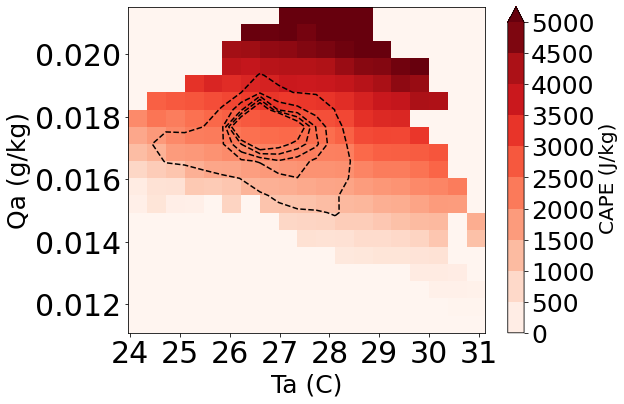

In [108]:
# Step 2: Mask to remove any NaN values in any of the three datasets
mask = ~np.isnan(cape_ctl_wet_mask_flat) & ~np.isnan(ta_ctl_wet_mask_flat) & ~np.isnan(qa_ctl_wet_mask_flat)

cape_clean = cape_ctl_wet_mask_flat[mask]
ta_clean = ta_ctl_wet_mask_flat[mask]
qa_clean = qa_ctl_wet_mask_flat[mask]

# Step 3: Create 2D histogram binning the qa and ta, using capeitation as color
# ctline number of bins for x and y (qa and ta)
x_bins = np.linspace(np.nanmin(ta_clean), np.nanmax(ta_clean), 20)  # Adjust bin size if needed
y_bins = np.linspace(np.nanmin(qa_clean), np.nanmax(qa_clean), 20)

# Create 2D histogram for binned capeitation data
cape_2d, x_edges, y_edges = np.histogram2d(ta_clean, qa_clean, bins=[x_bins, y_bins], weights=cape_clean)

# Count the number of data points in each bin (to avoid dividing by zero)
counts, _, _ = np.histogram2d(ta_clean, qa_clean, bins=[x_bins, y_bins])

# Avoid division by zero by replacing zeros in counts with NaNs
avg_cape = cape_2d / counts
avg_cape[np.isnan(avg_cape)] = 0  # Replace NaNs with 0 if needed
#avg_cape[avg_cape < 50] = np.nan

# Step 4: Plot using pcolormesh
plt.figure(figsize=(8, 6))

# Plot the 2D grid with colors representing capeitation
plt.pcolormesh(x_edges, y_edges, avg_cape.T, shading='auto', cmap='Reds', vmin=0, vmax=5000)
bounds = np.linspace(0, 5000, 11)
cbar = plt.colorbar(extend='max', ticks=bounds, boundaries=bounds)
cbar.ax.tick_params(labelsize=25)
cbar.set_label('CAPE (J/kg)', fontsize=20)

# Set custom contour levels
custom_contour_levels = np.linspace(100, 2000, 5)  # Define your desired contour levels

# Plot contour lines for the counts (frequency of W and qa)
plt.contour(x_edges[:-1], y_edges[:-1], counts.T, levels=custom_contour_levels, colors='black', linewidths=1.5, linestyles='--')

# Set axis labels
plt.xlabel('Ta (C)', fontsize=25)
plt.ylabel('Qa (g/kg)', fontsize=25)
#plt.title('capeitation Based on U600-U925 and qa', fontsize=14)

plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

plt.show()

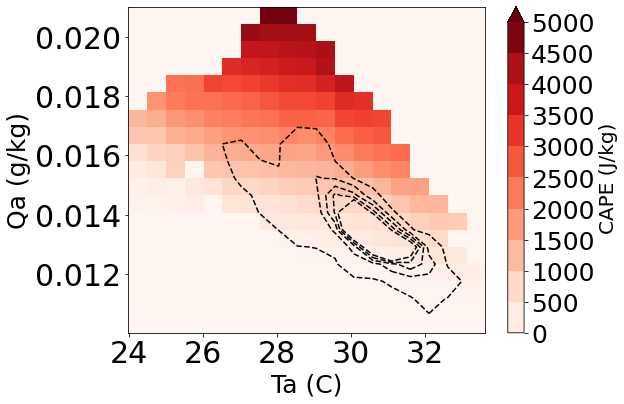

In [109]:
# Step 2: Mask to remove any NaN values in any of the three datasets
mask = ~np.isnan(cape_def_wet_mask_flat) & ~np.isnan(ta_def_wet_mask_flat) & ~np.isnan(qa_def_wet_mask_flat)

cape_clean = cape_def_wet_mask_flat[mask]
ta_clean = ta_def_wet_mask_flat[mask]
qa_clean = qa_def_wet_mask_flat[mask]

# Step 3: Create 2D histogram binning the qa and ta, using capeitation as color
# define number of bins for x and y (qa and ta)
x_bins = np.linspace(np.nanmin(ta_clean), np.nanmax(ta_clean), 20)  # Adjust bin size if needed
y_bins = np.linspace(np.nanmin(qa_clean), np.nanmax(qa_clean), 20)

# Create 2D histogram for binned capeitation data
cape_2d, x_edges, y_edges = np.histogram2d(ta_clean, qa_clean, bins=[x_bins, y_bins], weights=cape_clean)

# Count the number of data points in each bin (to avoid dividing by zero)
counts, _, _ = np.histogram2d(ta_clean, qa_clean, bins=[x_bins, y_bins])

# Avoid division by zero by replacing zeros in counts with NaNs
avg_cape = cape_2d / counts
avg_cape[np.isnan(avg_cape)] = 0  # Replace NaNs with 0 if needed
#avg_cape[avg_cape < 50] = np.nan

# Step 4: Plot using pcolormesh
plt.figure(figsize=(8, 6))

# Plot the 2D grid with colors representing capeitation
plt.pcolormesh(x_edges, y_edges, avg_cape.T, shading='auto', cmap='Reds', vmin=0, vmax=5000)
bounds = np.linspace(0, 5000, 11)
cbar = plt.colorbar(extend='max', ticks=bounds, boundaries=bounds)
cbar.ax.tick_params(labelsize=25)
cbar.set_label('CAPE (J/kg)', fontsize=20)

# Set custom contour levels
custom_contour_levels = np.linspace(100, 2000, 5)  # Define your desired contour levels

# Plot contour lines for the counts (frequency of W and qa)
plt.contour(x_edges[:-1], y_edges[:-1], counts.T, levels=custom_contour_levels, colors='black', linewidths=1.5, linestyles='--')

# Set axis labels
plt.xlabel('Ta (C)', fontsize=25)
plt.ylabel('Qa (g/kg)', fontsize=25)
#plt.title('capeitation Based on U600-U925 and qa', fontsize=14)

plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

plt.show()

In [89]:
cape_ctl_mask_f = cape_ctl_mask_flat[~np.isnan(cape_ctl_mask_flat)]
cape_def_mask_f = cape_def_mask_flat[~np.isnan(cape_def_mask_flat)]

In [110]:
cape_ctl_wet_mask_f = cape_ctl_wet_mask_flat[~np.isnan(cape_ctl_wet_mask_flat)]
cape_def_wet_mask_f = cape_def_wet_mask_flat[~np.isnan(cape_def_wet_mask_flat)]

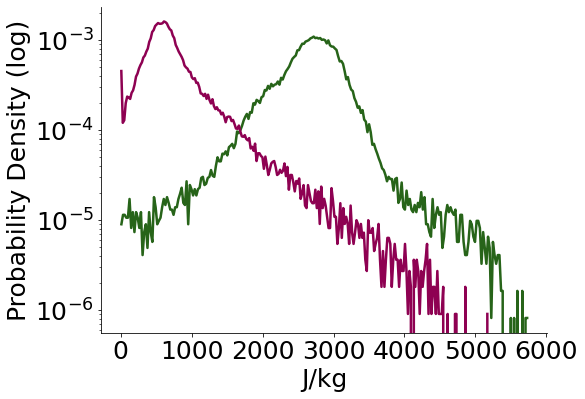

In [111]:
# Normalize the PDF
pdf_ctl, bin_edges_ctl = np.histogram(cape_ctl_wet_mask_f, bins=250, density=True)
pdf_def, bin_edges_def = np.histogram(cape_def_wet_mask_f, bins=250, density=True)

# Calculate the bin centers
bin_centers_ctl = 0.5*(bin_edges_ctl[1:] + bin_edges_ctl[:-1])
bin_centers_def = 0.5*(bin_edges_def[1:] + bin_edges_def[:-1])

# Plot the PDF
clr = ['darkkhaki', 'thistle'] 
# get color from BrBG
cmap = matplotlib.cm.get_cmap('PiYG')
left = cmap(0.0)
right = cmap(1.0)

fig = plt.figure(figsize=(8, 6))

plt.plot(bin_centers_ctl, pdf_ctl, label='CTL', color=right, linewidth=2.5)
plt.plot(bin_centers_def, pdf_def, label='DEF', color=left, linewidth=2.5)

# Set labels and title
plt.xlabel('J/kg', fontsize='25')
plt.ylabel('Probability Density (log)', fontsize='25')
#plt.title('PDF', fontsize='15')
#plt.yscale('log')
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.yscale('log')

#plt.xlim(0, 425)

# remove frame on upper and right side
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# add legend
#plt.legend(fontsize=15)

# Display the plot
plt.show()

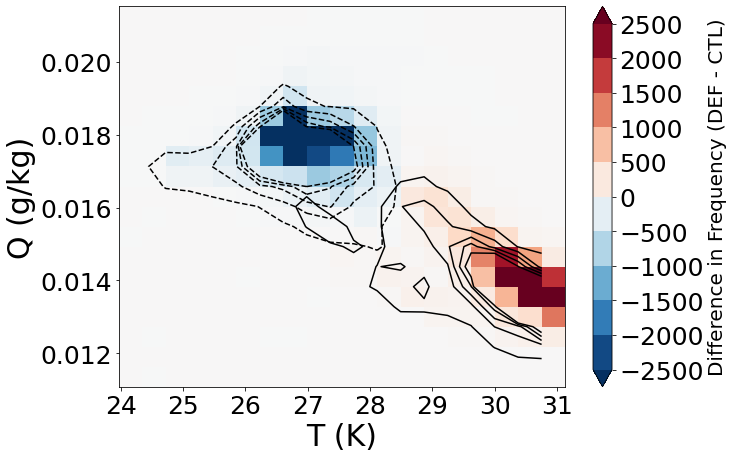

In [112]:
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Mask to remove any NaN values in any of the three datasets
mask_ctl = ~np.isnan(ta_ctl_wet_mask_flat) & ~np.isnan(qa_ctl_wet_mask_flat) & ~np.isnan(cape_ctl_wet_mask_flat)
mask_def = ~np.isnan(ta_def_wet_mask_flat) & ~np.isnan(qa_def_wet_mask_flat) & ~np.isnan(cape_def_wet_mask_flat)

U_diff_clean_ctl = ta_ctl_wet_mask_flat[mask_ctl]
TCW_clean_ctl = qa_ctl_wet_mask_flat[mask_ctl]
Precip_clean_ctl = cape_ctl_mask_flat[mask_ctl]

U_diff_clean_def = ta_def_wet_mask_flat[mask_def]
TCW_clean_def = qa_def_wet_mask_flat[mask_def]
Precip_clean_def = cape_def_mask_flat[mask_def]

# Step 3: Create a 2D histogram binning the TCW and U_diff, based on event frequency
x_bins = np.linspace(np.nanmin(U_diff_clean_ctl), np.nanmax(U_diff_clean_ctl), 20)
y_bins = np.linspace(np.nanmin(TCW_clean_ctl), np.nanmax(TCW_clean_ctl), 20)

# Create 2D histograms counting the number of events in each bin
counts_ctl, x_edges_ctl, y_edges_ctl = np.histogram2d(U_diff_clean_ctl, TCW_clean_ctl, bins=[x_bins, y_bins])
counts_def, x_edges_def, y_edges_def = np.histogram2d(U_diff_clean_def, TCW_clean_def, bins=[x_bins, y_bins])

# Calculate the difference between DEF and CTL
counts_diff = counts_def - counts_ctl

# Step 4: Plot the difference using a diverging color map (RdBu)
plt.figure(figsize=(10, 7))

# Plot the difference between DEF and CTL
m = plt.pcolormesh(x_edges_ctl, y_edges_ctl, counts_diff.T, shading='auto', cmap='RdBu_r', vmin=-2500, vmax=2500 ) #vmin=-np.max(np.abs(counts_diff)), vmax=np.max(np.abs(counts_diff)))

# Optional: Overlay contours for CTL to provide reference points
plt.contour(x_edges_ctl[:-1], y_edges_ctl[:-1], counts_ctl.T, levels=np.linspace(100, 1000, 5), colors='black', linewidths=1.5, linestyles='--')
plt.contour(x_edges_def[:-1], y_edges_def[:-1], counts_def.T, levels=np.linspace(100, 1000, 5), colors='black', linewidths=1.5, linestyles='-')

# Add a colorbar for the difference plot
# Add colorbar for precipitation
bounds = np.linspace(-2500, 2500, 11)
cbar = plt.colorbar(m, extend='both', ticks=bounds, boundaries=bounds)
cbar.ax.tick_params(labelsize=25)
cbar.set_label('Difference in Frequency (DEF - CTL)', fontsize=20)

# Set axis labels
plt.xlabel('T (K)', fontsize=30)
plt.ylabel('Q (g/kg)', fontsize=30)

# Set tick size for the plot
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.show()


# Test with dask

In [24]:
data_path_td_ctl = '/scratch/m/m300948/test_04/3d/dew_point_temp/ctl_daily_td_plev_20220101*.nc'
td_ctl = xr.open_mfdataset(data_path_td_ctl, parallel=True) #, chunks={'time': 30, 'plev': -1, 'lat': 100, 'lon': 100}
td_ctl

<xarray.Dataset>
Dimensions:  (time: 4, lon: 800, lat: 800, plev: 23)
Coordinates:
  * time     (time) datetime64[ns] 2022-01-01 ... 2022-01-01T18:00:00
  * lon      (lon) float64 -99.95 -99.85 -99.75 -99.65 ... -20.25 -20.15 -20.05
  * lat      (lat) float64 -59.95 -59.85 -59.75 -59.65 ... 19.75 19.85 19.95
  * plev     (plev) float64 1e+05 9.75e+04 9.5e+04 ... 3e+03 1e+03 100.0
Data variables:
    ta       (time, plev, lat, lon) float32 dask.array<chunksize=(4, 23, 800, 800), meta=np.ndarray>
    td       (time, plev, lat, lon) float64 dask.array<chunksize=(4, 23, 800, 800), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.0.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Wed Jan 22 10:39:12 2025: cdo -O remap,/scratch/m/m300948/R...
    CDO:          Climate Data Operators version 2.0.3 (https://mpimet.mpg.de...

In [27]:
lat_start = -17
lat_end = 9
lon_start = -80
lon_end = -45

In [37]:
td_ctl = td_ctl.sel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end)).isel(time=0)
td_ctl

<xarray.Dataset>
Dimensions:  (lon: 350, lat: 260, plev: 23)
Coordinates:
    time     datetime64[ns] 2022-01-01
  * lon      (lon) float64 -79.95 -79.85 -79.75 -79.65 ... -45.25 -45.15 -45.05
  * lat      (lat) float64 -16.95 -16.85 -16.75 -16.65 ... 8.65 8.75 8.85 8.95
  * plev     (plev) float64 1e+05 9.75e+04 9.5e+04 ... 3e+03 1e+03 100.0
Data variables:
    ta       (plev, lat, lon) float32 291.8 291.8 291.8 ... 246.3 247.1 248.0
    td       (plev, lat, lon) float64 16.49 15.3 15.95 ... -111.8 -112.5 -113.5
Attributes:
    CDI:          Climate Data Interface version 2.0.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Wed Jan 22 10:39:12 2025: cdo -O remap,/scratch/m/m300948/R...
    CDO:          Climate Data Operators version 2.0.3 (https://mpimet.mpg.de...

In [38]:
pressure = td_ctl.plev.broadcast_like(td_ctl.ta) /100 

In [31]:
import xarray as xr
import numpy as np
from metpy.units import units
from metpy.calc import cape_cin, parcel_profile

def cal_cape_cin(pressure_data, temperature_data, dew_temperature_data):
    """
    Function to calculate CAPE and CIN for a single grid point.
    """
    T = (temperature_data - 273.15) * units.degC
    Td = dew_temperature_data * units.degC
    p = pressure_data * units.hPa
    
    #print(p, T[0], Td[0])
  
    prof = parcel_profile(p, T[0], Td[0]).to('degC')
    cape, cin = cape_cin(p, T, Td, prof)
    return cape.magnitude, cin.magnitude

In [41]:
# Apply xr.apply_ufunc
cape_cin_ctl_result = xr.apply_ufunc(
    cal_cape_cin,
    
    pressure.load(),
    td_ctl.ta.load(),
    td_ctl.td.load(),
    
    input_core_dims=[['plev'], ['plev'], ['plev']], 
    output_core_dims=[[],[]], # CAPE and CIN are scalars
    vectorize=True,  # Vectorize the operation
    dask='parallelized',  # Use parallelized computation if using dask
    output_dtypes=[float, float]
)

# without time dimension, it takes 30mins to be completed

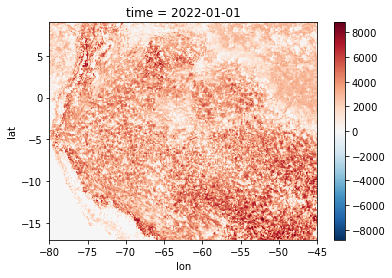

In [43]:
cape_cin_ctl_result[0].plot()